# Descriptive statistics

This notebook uses the Adult Income dataset. The data is already split into a training file (`adult.data`) and a test file (`adult.test`), and we keep this split:

- The analysis (descriptive statistics, outliers, correlations) is done on the **training data only**.
- The test data is only cleaned with the same fixed rules (income labels, missing values, duplicates) and transformed with the values learned from the training data (encoded columns, scaling). This way the test data stays unseen until the models are evaluated.

At the end, the cleaned, encoded and standardized train and test data are saved to the `cleaned_data` folder.

## Getting ready

Import libraries.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("Libraries loaded.")

Libraries loaded.


## Load the data and inspect its structure

In [2]:
column_names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

train = pd.read_csv("../active_dataset(adult_income)/adult.data",
                    names=column_names,
                    na_values="?",
                    skipinitialspace=True,
                    header=None)

# The first line of adult.test is a comment, so it is skipped
test = pd.read_csv("../active_dataset(adult_income)/adult.test",
                   names=column_names,
                   na_values="?",
                   skipinitialspace=True,
                   header=None,
                   skiprows=1)

# Keep the raw data for the checks below
train_original = train.copy()
test_original = test.copy()

# The test file writes income as ">50K." and "<=50K." - remove the dot
test["income"] = test["income"].str.replace(".", "", regex=False)

# Display the first five observations
display(train.head())

# Dataset dimensions
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of variables:", len(column_names))

# Variable names and data types
print("\nVariable information (train):")
train.info()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Train shape: (32561, 15)
Test shape: (16281, 15)
Number of variables: 15

Variable information (train):
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


#### Check the income labels

`train_original` and `test_original` contain the raw data. The test file writes the labels with a dot at the end, so without the fix there would be four different income values instead of two.

In [3]:
print("Income values in adult.data (train):")
print(train_original["income"].value_counts())

print("\nIncome values in adult.test (test), before removing the dot:")
print(test_original["income"].value_counts())

print("\nIncome values in test after removing the dot:")
print(test["income"].value_counts())

Income values in adult.data (train):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Income values in adult.test (test), before removing the dot:
income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64

Income values in test after removing the dot:
income
<=50K    12435
>50K      3846
Name: count, dtype: int64


#### Check for missing values

In [4]:
missing_values = pd.DataFrame({
    "Missing (train)": train_original.isna().sum(),
    "Missing (train) (%)": train_original.isna().mean() * 100,
    "Missing (test)": test_original.isna().sum(),
    "Missing (test) (%)": test_original.isna().mean() * 100
})

display(missing_values.round(2))

,Missing (train),Missing (train) (%),Missing (test),Missing (test) (%)
age,0,0.00,0,0.00
workclass,1836,5.64,963,5.91
fnlwgt,0,0.00,0,0.00
education,0,0.00,0,0.00
education-num,0,0.00,0,0.00
marital-status,0,0.00,0,0.00
occupation,1843,5.66,966,5.93
relationship,0,0.00,0,0.00
race,0,0.00,0,0.00
sex,0,0.00,0,0.00


Missing values are only in `workclass`, `occupation` and `native-country`. In the training data 2,399 rows (7.37%) have at least one missing value, in the test data 1,221 rows (7.50%).

We delete these rows in both files. This is a fixed rule (a row is deleted if a value is missing), it does not use any information from the data, so it can be applied to the test data too. There are still more than 30,000 training rows left, which is enough for the analysis.

The deleted rows are not random: in the training data, people with missing values earn >50K less often (13.9%) than the others (24.9%). So after deleting, people with higher income are a bit overrepresented.

#### Delete rows with missing values

In [5]:
print("Rows before - train:", len(train), " test:", len(test))

train = train.dropna()
train = train.reset_index(drop=True)

test = test.dropna()
test = test.reset_index(drop=True)

print("Rows after  - train:", len(train), " test:", len(test))

Rows before - train: 32561  test: 16281
Rows after  - train: 30162  test: 15060


#### Check for duplicate rows

In [6]:
# Number of rows that are an exact copy of an earlier row
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

# Show the duplicated training rows together with their copies
duplicate_rows = train[train.duplicated(keep=False)]
display(duplicate_rows.sort_values(by=list(train.columns)).head(10))

Duplicate rows in train:

 23
Duplicate rows in test: 5


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
16376,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
17329,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6445,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
19753,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
14071,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
19910,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3594,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
29640,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
5326,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
10746,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


#### Delete duplicate rows

Only the first occurrence of each row is kept, separately in each file.

In [7]:
print("Rows before - train:", len(train), " test:", len(test))

train = train.drop_duplicates()
train = train.reset_index(drop=True)

test = test.drop_duplicates()
test = test.reset_index(drop=True)

print("Rows after  - train:", len(train), " test:", len(test))

Rows before - train: 30162  test: 15060
Rows after  - train: 30139  test: 15055


## Descriptive statistics

From here on, the analysis uses only the training data (`train`).

#### Descriptive statistics for numerical variables

In [8]:
numeric_columns = [ "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Basic descriptive statistics
numeric_statistics = train[numeric_columns].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,30139.0,38.441720,13.131426,17.0,28.0,37.0,47.0,90.0
fnlwgt,30139.0,189795.025980,105658.624341,13769.0,117627.5,178417.0,237604.5,1484705.0
education-num,30139.0,10.122532,2.548738,1.0,9.0,10.0,13.0,16.0
capital-gain,30139.0,1092.841202,7409.110596,0.0,0.0,0.0,0.0,99999.0
capital-loss,30139.0,88.439928,404.445239,0.0,0.0,0.0,0.0,4356.0
hours-per-week,30139.0,40.934703,11.978753,1.0,40.0,40.0,45.0,99.0


#### More detailed descriptive statistics

In [9]:
descriptive_statistics = []

for column in numeric_columns:

    data = pd.to_numeric(train[column], errors="coerce").dropna()

    # Mode
    mode_values = data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and maximum
    minimum = data.min()
    maximum = data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": column,
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,38.441720,37.0,36,17,28.0,37.0,47.0,90,73,19.0,1.724343e+02,13.131426,0.528971,-0.149394
1,fnlwgt,189795.025980,178417.0,203488,13769,117627.5,178417.0,237604.5,1484705,1470936,119977.0,1.116374e+10,105658.624341,1.460055,6.397937
2,education-num,10.122532,10.0,9,1,9.0,10.0,13.0,16,15,4.0,6.496068e+00,2.548738,-0.302845,0.638573
3,capital-gain,1092.841202,0.0,0,0,0.0,0.0,0.0,99999,99999,0.0,5.489492e+07,7409.110596,11.898104,153.546769
4,capital-loss,88.439928,0.0,0,0,0.0,0.0,0.0,4356,4356,0.0,1.635760e+05,404.445239,4.524409,19.492329
5,hours-per-week,40.934703,40.0,40,1,40.0,40.0,45.0,99,98,5.0,1.434905e+02,11.978753,0.332386,3.169360


#### Frequency tables for categorical variables

In [10]:
categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = train[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(train) * 100
    )

    display(frequency_table)


workclass


,Frequency,Percentage (%)
workclass,,
Private,22264,73.871064
Self-emp-not-inc,2498,8.288264
Local-gov,2067,6.858224
State-gov,1279,4.243671
Self-emp-inc,1074,3.563489
Federal-gov,943,3.128836
Without-pay,14,0.046451



education


,Frequency,Percentage (%)
education,,
HS-grad,9834,32.628820
Some-college,6669,22.127476
Bachelors,5042,16.729155
Masters,1626,5.395003
Assoc-voc,1307,4.336574
11th,1048,3.477222
Assoc-acdm,1008,3.344504
10th,820,2.720727
7th-8th,556,1.844786



marital-status


...

,Frequency,Percentage (%)
race,,
White,25912,85.974983
Black,2816,9.343376
Asian-Pac-Islander,894,2.966256
Amer-Indian-Eskimo,286,0.948937
Other,231,0.766449



sex


,Frequency,Percentage (%)
sex,,
Male,20366,67.573576
Female,9773,32.426424



native-country


,Frequency,Percentage (%)
native-country,,
United-States,27487,91.200770
Mexico,606,2.010684
Philippines,188,0.623777
Germany,128,0.424699
Puerto-Rico,109,0.361658
Canada,107,0.355022
India,100,0.331796
El-Salvador,100,0.331796
Cuba,92,0.305252


#### Cross tabulations (Crosstabs)

In [11]:
crosstab_pairs = [
    ("education", "income"),
    ("marital-status", "income"),
    ("relationship", "income")
]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        train[row_variable],
        train[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        train[row_variable],
        train[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): education × income


income,<=50K,>50K
education,,
10th,761,59
11th,989,59
12th,348,29
1st-4th,143,6
5th-6th,275,12
7th-8th,521,35
9th,430,25
Assoc-acdm,752,256
Assoc-voc,963,344



Crosstab (total percentages): education × income


income,<=50K,>50K
education,,
10th,2.52,0.20
11th,3.28,0.20
12th,1.15,0.10
1st-4th,0.47,0.02
5th-6th,0.91,0.04
7th-8th,1.73,0.12
9th,1.43,0.08
Assoc-acdm,2.50,0.85
Assoc-voc,3.20,1.14



Crosstab (frequencies): marital-status × income


...

income,<=50K,>50K
marital-status,,
Divorced,12.48,1.50
Married-AF-spouse,0.04,0.03
Married-civ-spouse,25.42,21.22
Married-spouse-absent,1.12,0.10
Never-married,30.66,1.56
Separated,2.90,0.22
Widowed,2.48,0.27



Crosstab (frequencies): relationship × income


income,<=50K,>50K
relationship,,
Husband,6780,5677
Not-in-family,6891,823
Other-relative,854,35
Own-child,4398,64
Unmarried,2998,213
Wife,712,694



Crosstab (total percentages): relationship × income


income,<=50K,>50K
relationship,,
Husband,22.50,18.84
Not-in-family,22.86,2.73
Other-relative,2.83,0.12
Own-child,14.59,0.21
Unmarried,9.95,0.71
Wife,2.36,2.30


#### z-scores

In [12]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        train[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=train.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.042516,-1.062676,1.128996,0.145925,-0.218673,-0.078031
1,0.880215,-1.007829,1.128996,-0.147502,-0.218673,-2.332060
2,-0.033639,0.244669,-0.440434,-0.147502,-0.218673,-0.078031
3,1.108678,0.425206,-1.225149,-0.147502,-0.218673,-0.078031
4,-0.795183,1.406572,1.128996,-0.147502,-0.218673,-0.078031


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,0.0,1.0,-1.6329,3.9264
1,fnlwgt,-0.0,1.0,-1.6660,12.2558
2,education-num,0.0,1.0,-3.5793,2.3061
3,capital-gain,0.0,1.0,-0.1475,13.3495
4,capital-loss,0.0,1.0,-0.2187,10.5518
5,hours-per-week,-0.0,1.0,-3.3338,4.8474


#### Detecting outliers using z-scores

In [13]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=train.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(train) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = train.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,119,0.39
1,fnlwgt,322,1.07
2,education-num,193,0.64
3,capital-gain,198,0.66
4,capital-loss,1381,4.58
5,hours-per-week,402,1.33



z-score outliers: age


,income,age,z-score
901,<=50K,78,3.012539
2460,<=50K,78,3.012539
5540,>50K,78,3.012539
13779,<=50K,78,3.012539
12616,<=50K,78,3.012539
...,...,...,...
26364,<=50K,90,3.926393
22269,<=50K,90,3.926393
28736,<=50K,90,3.926393
29879,<=50K,90,3.926393



z-score outliers: fnlwgt


,income,fnlwgt,z-score
26466,<=50K,506830,3.000609
6120,>50K,506858,3.000874
37,<=50K,507875,3.010500
1731,<=50K,508336,3.014863
7831,<=50K,508548,3.016869
...,...,...,...
7612,>50K,1226583,9.812783
14418,<=50K,1268339,10.207987
15497,<=50K,1366120,11.133445
16809,<=50K,1455435,11.978776


...

,income,capital-gain,z-score
17463,>50K,25124,3.243514
20800,>50K,25124,3.243514
6000,>50K,25236,3.258631
648,>50K,25236,3.258631
10924,>50K,25236,3.258631
...,...,...,...
28807,>50K,99999,13.349484
29598,>50K,99999,13.349484
29462,>50K,99999,13.349484
29842,>50K,99999,13.349484



z-score outliers: capital-loss


,income,capital-loss,z-score
188,<=50K,1340,3.094562
29005,<=50K,1340,3.094562
1396,<=50K,1340,3.094562
19327,<=50K,1340,3.094562
2412,<=50K,1340,3.094562
...,...,...,...
10998,<=50K,3770,9.102892
14762,<=50K,3770,9.102892
22043,<=50K,3900,9.424325
18912,<=50K,3900,9.424325



z-score outliers: hours-per-week


,income,hours-per-week,z-score
22494,<=50K,1,-3.333850
23226,<=50K,1,-3.333850
19364,<=50K,1,-3.333850
21263,<=50K,1,-3.333850
18299,<=50K,1,-3.333850
...,...,...,...
9063,<=50K,99,4.847438
1735,>50K,99,4.847438
9083,<=50K,99,4.847438
29335,>50K,99,4.847438


#### Detecting outliers using the IQR method

In [14]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=train.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        train[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = train.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,28.0,47.0,19.0,-0.5,75.5,168,0.5574
1,fnlwgt,117627.5,237604.5,119977.0,-62338.0,417570.0,904,2.9994
2,education-num,9.0,13.0,4.0,3.0,19.0,193,0.6404
3,capital-gain,0.0,0.0,0.0,0.0,0.0,2538,8.4210
4,capital-loss,0.0,0.0,0.0,0.0,0.0,1427,4.7347
5,hours-per-week,40.0,45.0,5.0,32.5,52.5,7947,26.3678



IQR outliers: age


,income,age
92,>50K,76
301,<=50K,76
3848,<=50K,76
3334,<=50K,76
4588,<=50K,76
...,...,...
22269,<=50K,90
26364,<=50K,90
28736,<=50K,90
29879,<=50K,90



IQR outliers: fnlwgt


,income,fnlwgt
28259,<=50K,417605
2988,<=50K,417657
27628,<=50K,417668
26088,<=50K,417668
16220,<=50K,417668
...,...,...
7612,>50K,1226583
14418,<=50K,1268339
15497,<=50K,1366120
16809,<=50K,1455435


...

,income,capital-gain
5766,<=50K,114
4319,<=50K,114
25262,<=50K,114
18391,<=50K,114
21129,<=50K,114
...,...,...
1361,>50K,99999
23497,>50K,99999
22708,>50K,99999
22828,>50K,99999



IQR outliers: capital-loss


,income,capital-loss
18774,<=50K,155
10424,<=50K,213
16001,<=50K,213
26820,<=50K,213
3367,<=50K,213
...,...,...
14762,<=50K,3770
10998,<=50K,3770
22043,<=50K,3900
18912,<=50K,3900



IQR outliers: hours-per-week


,income,hours-per-week
22494,<=50K,1
23226,<=50K,1
19364,<=50K,1
21263,<=50K,1
18299,<=50K,1
...,...,...
21901,>50K,99
6091,<=50K,99
20574,<=50K,99
20887,<=50K,99


#### Compare the two outlier-detection methods

In [15]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,119,168,-49
1,fnlwgt,322,904,-582
2,education-num,193,193,0
3,capital-gain,198,2538,-2340
4,capital-loss,1381,1427,-46
5,hours-per-week,402,7947,-7545


#### Box-and-whisker diagram (boxplot)

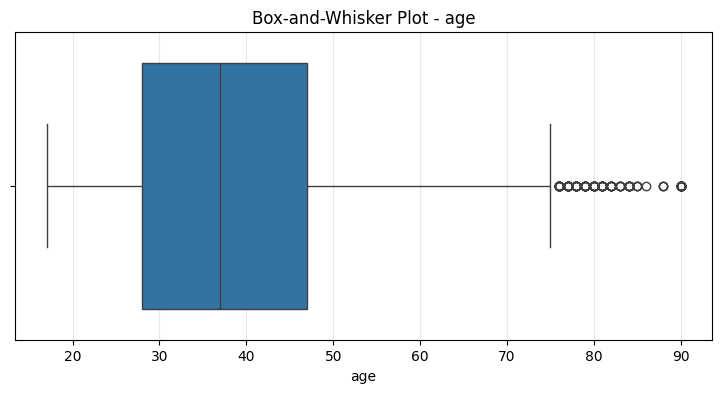

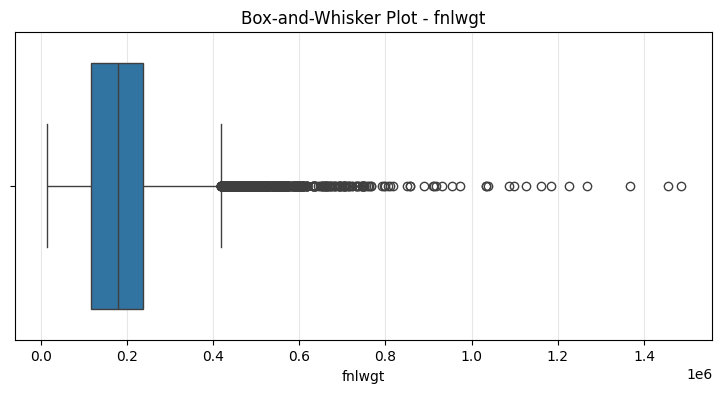

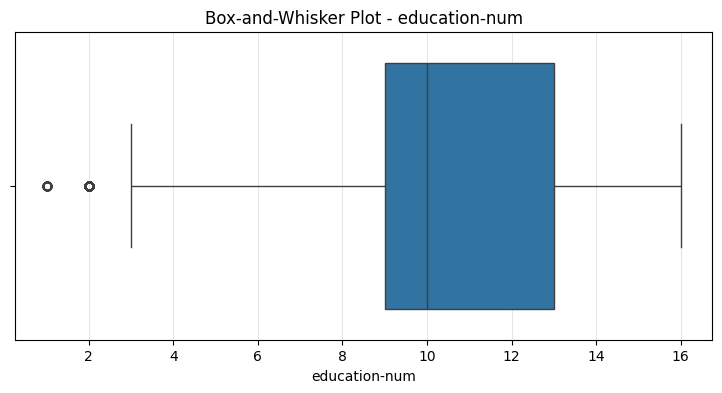

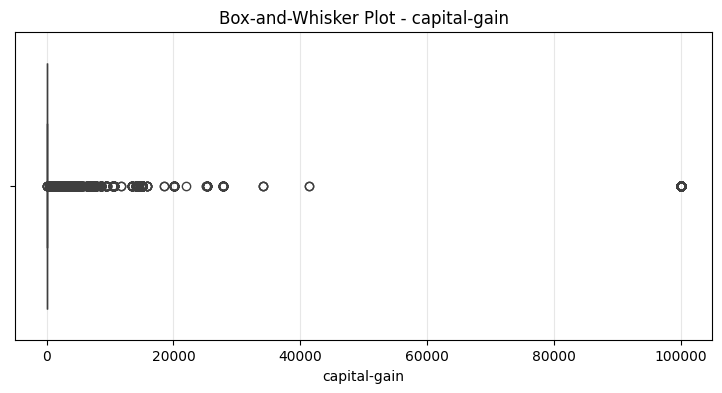

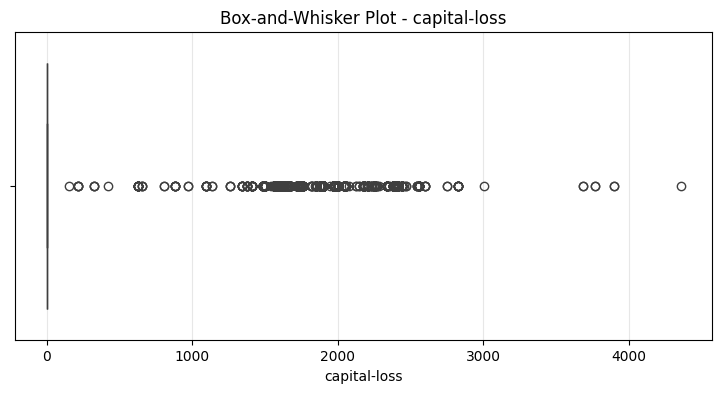

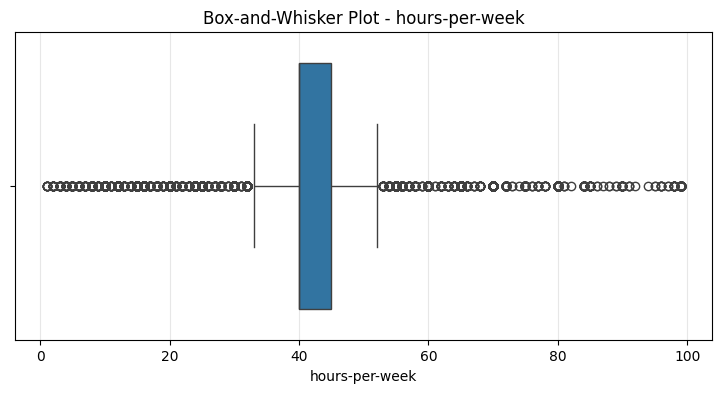

In [16]:
for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=train,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot - {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

#### Correlation coefficient (r)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.0000,-0.0763,0.0432,0.0802,0.0601,0.1013
fnlwgt,-0.0763,1.0000,-0.0452,0.0004,-0.0098,-0.0230
education-num,0.0432,-0.0452,1.0000,0.1245,0.0796,0.1528
capital-gain,0.0802,0.0004,0.1245,1.0000,-0.0323,0.0804
capital-loss,0.0601,-0.0098,0.0796,-0.0323,1.0000,0.0524
hours-per-week,0.1013,-0.0230,0.1528,0.0804,0.0524,1.0000


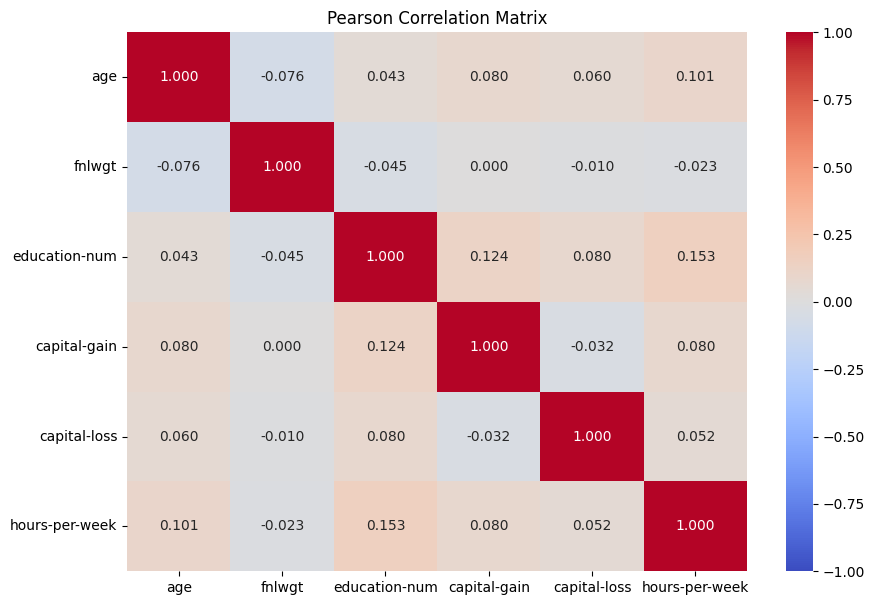

In [17]:

# Correlation matrix
correlation_matrix = train[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

# Handling outliers

The z-score and IQR methods found very different numbers of outliers, because some variables are very skewed (for example over 90% of the values of `capital-gain` and `capital-loss` are 0, so IQR marks every non-zero value as an outlier).

We decided to keep all values as they are:

- The extreme values are real, not errors: there are people aged 90, people working 99 hours per week, and people with large capital gains (99999 is the highest value recorded by the census).
- Deleting or changing them would remove real information about the people with the highest incomes, which is exactly what we want to study.
- `fnlwgt` is a census weight, not information about the person. It is dropped in the encoding.

#### Log transformation of capital-gain and capital-loss

`capital-gain` and `capital-loss` are extremely skewed: most people have 0 and a few have very large values (up to 99999). We keep the original columns and add a log(1 + x) version. It compresses the scale (99999 becomes about 11.5), so the few very large values do not dominate the regression and the distances in clustering. No value is removed.

log(1 + x) is a fixed formula, it does not learn anything from the data, so it is applied the same way to train and test.

In [18]:
for data in [train, test]:
    data["capital-gain-log"] = np.log1p(data["capital-gain"])
    data["capital-loss-log"] = np.log1p(data["capital-loss"])

print("Skewness before and after the log transformation (train):")
print("capital-gain:", round(train["capital-gain"].skew(), 2), "->", round(train["capital-gain-log"].skew(), 2))
print("capital-loss:", round(train["capital-loss"].skew(), 2), "->", round(train["capital-loss-log"].skew(), 2))

Skewness before and after the log transformation (train):
capital-gain: 11.9 -> 3.07
capital-loss: 4.52 -> 4.27


# Feature engineering

New features (created the same way for train and test):

- `capital-net`: capital gain minus capital loss
- `has-capital`: 1 if the person has any capital gain or loss, otherwise 0
- `age-group`: 17-24, 25-34, 35-44, 45-54, 55-64, 65+
- `hours-category`: Part-time (under 35 h), Full-time (35-40 h), Overtime (over 40 h)
- `is-married`: 1 if `Married-civ-spouse` or `Married-AF-spouse`, otherwise 0

In [19]:
for data in [train, test]:

    data["capital-net"] = data["capital-gain"] - data["capital-loss"]

    data["has-capital"] = ((data["capital-gain"] > 0) | (data["capital-loss"] > 0)).astype(int)

    data["is-married"] = data["marital-status"].isin(["Married-civ-spouse", "Married-AF-spouse"]).astype(int)

    data["age-group"] = pd.cut(
        data["age"],
        bins=[16, 24, 34, 44, 54, 64, 100],
        labels=["17-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    )

    data["hours-category"] = pd.cut(
        data["hours-per-week"],
        bins=[0, 34, 40, 100],
        labels=["Part-time", "Full-time", "Overtime"]
    )

new_features = [
    "capital-net",
    "has-capital",
    "is-married",
    "age-group",
    "hours-category"
]

display(train[new_features].head(10))

,capital-net,has-capital,is-married,age-group,hours-category
0,2174,1,0,35-44,Full-time
1,0,0,1,45-54,Part-time
2,0,0,0,35-44,Full-time
3,0,0,1,45-54,Full-time
4,0,0,1,25-34,Full-time
5,0,0,1,35-44,Full-time
6,0,0,0,45-54,Part-time
7,0,0,1,45-54,Overtime
8,14084,1,0,25-34,Overtime
9,5178,1,1,35-44,Full-time


#### Frequency tables of the new categorical features

In [20]:
for column in ["has-capital", "is-married", "age-group", "hours-category"]:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = train[column].value_counts().sort_index().to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(train) * 100
    )

    display(frequency_table.round(2))


has-capital


,Frequency,Percentage (%)
has-capital,,
0,26174,86.84
1,3965,13.16



is-married


,Frequency,Percentage (%)
is-married,,
0,16059,53.28
1,14080,46.72



age-group


,Frequency,Percentage (%)
age-group,,
17-24,4861,16.13
25-34,8036,26.66
35-44,7802,25.89
45-54,5617,18.64
55-64,2849,9.45
65+,974,3.23



hours-category


,Frequency,Percentage (%)
hours-category,,
Part-time,4685,15.54
Full-time,16262,53.96
Overtime,9192,30.50


# Data Encoding

The `encode()` function:

- `sex`: 1 = Male, 0 = Female
- `native-country`: replaced by `is_us` (1 = United-States, 0 = other)
- `workclass`, `marital-status`, `occupation`, `relationship`, `race`: one-hot encoding with `drop_first=True`
- drops `education` (same information as `education-num`) and `fnlwgt` (census weight)
- drops `capital-gain` and `capital-loss`, because we use the log versions instead
- drops `capital-net`, `is-married`, `age-group`, `hours-category`, because they repeat information that is already in the data (we use them only for the analysis)
- `income` is kept separately as the target (1 = >50K)

The encoded columns come from the training data. The test data is encoded with all categories and then gets exactly the same columns in the same order. This way the reference category (the one removed by `drop_first`) is always the one from the training data, even if a category is missing in the test data. A category that appears only in the test data becomes all 0, like the reference category.

In [21]:
def encode(data, drop_first=True):
    data = data.copy()

    # Binary columns
    data["sex"] = (data["sex"] == "Male").astype(int)
    data["is_us"] = (data["native-country"] == "United-States").astype(int)

    # Drop columns not needed (education is covered by education-num)
    data = data.drop(columns=["education", "native-country", "fnlwgt", "income"],
                     errors="ignore")

    # Use the log versions of capital-gain and capital-loss
    data = data.drop(columns=["capital-gain", "capital-loss"], errors="ignore")

    # Drop the new features that repeat information already in the data
    data = data.drop(columns=["capital-net", "is-married", "age-group", "hours-category"],
                     errors="ignore")

    # One-hot encode the remaining text columns
    return pd.get_dummies(
        data,
        columns=["workclass", "marital-status", "occupation", "relationship", "race"],
        drop_first=drop_first,
        dtype=int,
    )

In [22]:
train_encoded = encode(train)

# Test is encoded with all categories, then it gets exactly the same columns as train, in the same order.
# The column of train's reference category is removed by reindex, so the reference category is always the one from train.
test_encoded = encode(test, drop_first=False)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# Target variable as 0/1: 1 = earns >50K
y_train = (train["income"] == ">50K").astype(int)
y_test = (test["income"] == ">50K").astype(int)

print("train_encoded shape:", train_encoded.shape)
print("test_encoded shape:", test_encoded.shape)
print(train_encoded.dtypes.value_counts())   # should be all numbers, no 'object'/'str'
print("Missing values:", train_encoded.isna().sum().sum() + test_encoded.isna().sum().sum())
print("Non-numeric columns:", train_encoded.select_dtypes(exclude="number").columns.tolist())
print("Share earning >50K - train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

display(train_encoded.head())

train_encoded shape:

 (30139, 42)
test_encoded shape: (15055, 42)
int64      40
float64     2
Name: count, dtype: int64
Missing values: 0
Non-numeric columns: []
Share earning >50K - train: 0.249  test: 0.246


,age,education-num,sex,hours-per-week,capital-gain-log,capital-loss-log,has-capital,is_us,workclass_Local-gov,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,13,1,40,7.684784,0.0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
1,50,13,1,13,0.000000,0.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38,9,1,40,0.000000,0.0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,1
3,53,7,1,40,0.000000,0.0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,40,0.000000,0.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


# Standardization

The numerical columns have very different ranges, for example `age` goes up to 90, `education-num` up to 16 and `capital-gain-log` only up to about 11.5. For k-means and DBSCAN this matters, because they use distances. So we standardized the numerical columns to mean 0 and standard deviation 1: z = (x - mean) / std.

The mean and standard deviation are calculated on the training data, and the test data is scaled with the same values. So the test data will not have exactly mean 0 and standard deviation 1, but it is on the same scale as the training data.

The 0/1 columns are not standardized.

In [23]:
scale_columns = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain-log",
    "capital-loss-log"
]

train_scaled = train_encoded.copy()
test_scaled = test_encoded.copy()

# The scaler learns the mean and standard deviation from the training data only
scaler = StandardScaler()
scaler.fit(train_encoded[scale_columns])

train_scaled[scale_columns] = scaler.transform(train_encoded[scale_columns])
test_scaled[scale_columns] = scaler.transform(test_encoded[scale_columns])

print("Train before standardization:")
display(train_encoded[scale_columns].describe().T[["mean", "std", "min", "max"]].round(3))

print("Train after standardization:")
display(train_scaled[scale_columns].describe().T[["mean", "std", "min", "max"]].round(3))

print("Test after standardization (with the values from train):")
display(test_scaled[scale_columns].describe().T[["mean", "std", "min", "max"]].round(3))

Train before standardization:


,mean,std,min,max
age,38.442,13.131,17.0,90.000
education-num,10.123,2.549,1.0,16.000
hours-per-week,40.935,11.979,1.0,99.000
capital-gain-log,0.744,2.471,0.0,11.513
capital-loss-log,0.355,1.596,0.0,8.380


Train after standardization:


,mean,std,min,max
age,0.0,1.0,-1.633,3.926
education-num,0.0,1.0,-3.579,2.306
hours-per-week,-0.0,1.0,-3.334,4.847
capital-gain-log,-0.0,1.0,-0.301,4.357
capital-loss-log,-0.0,1.0,-0.223,5.029


Test after standardization (with the values from train):


,mean,std,min,max
age,0.025,1.019,-1.633,3.926
education-num,-0.004,1.004,-3.579,2.306
hours-per-week,0.002,1.007,-3.334,4.847
capital-gain-log,-0.004,0.995,-0.301,4.357
capital-loss-log,0.000,1.002,-0.223,4.938


# Exploratory data analysis

#### Share of people earning >50K in each group

The red line shows the share for the whole dataset.

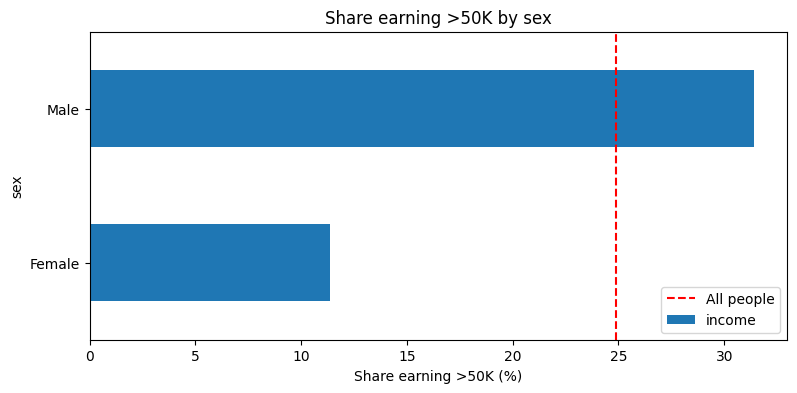

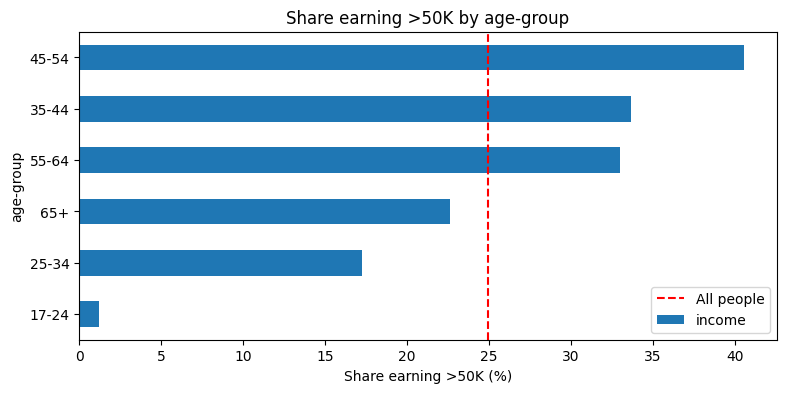

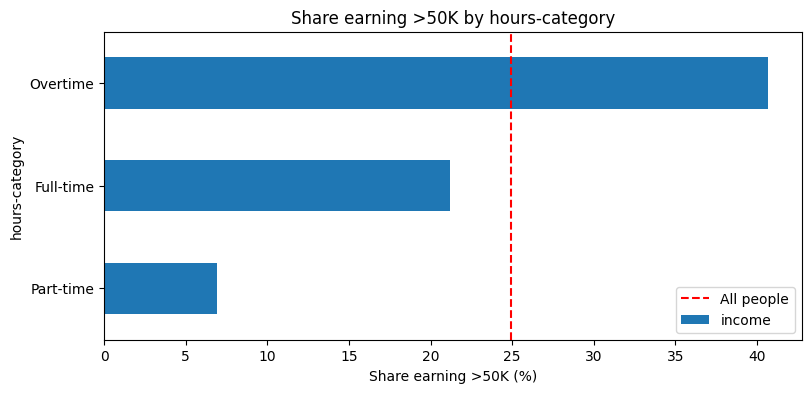

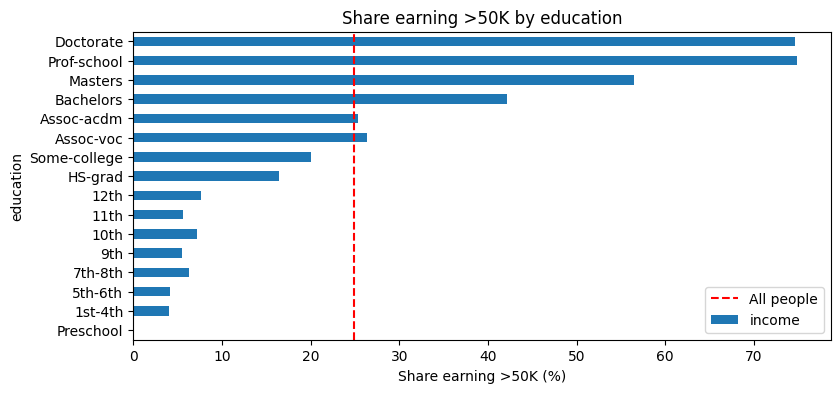

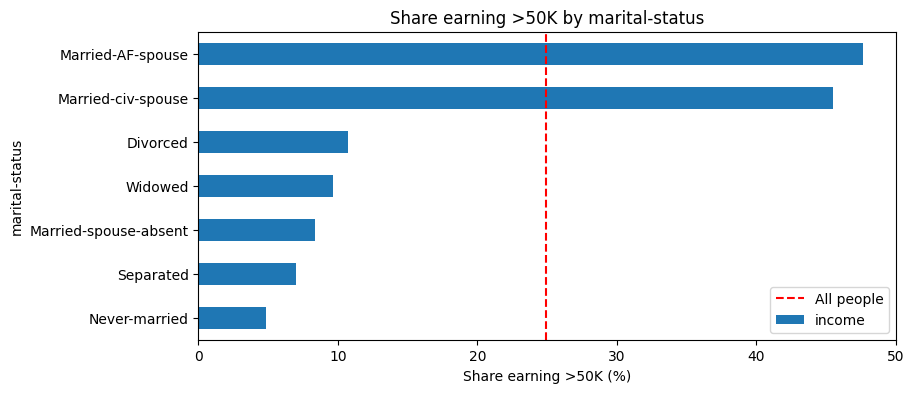

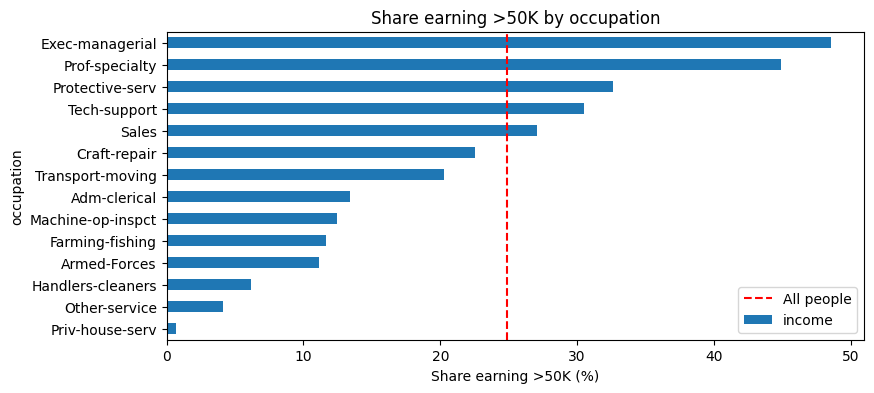

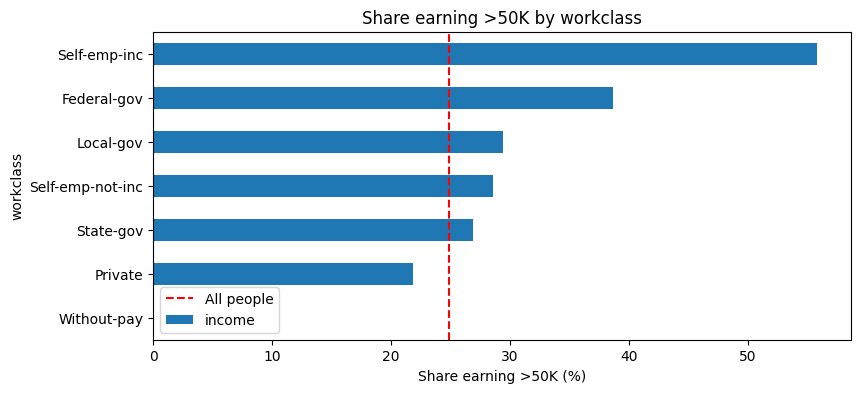

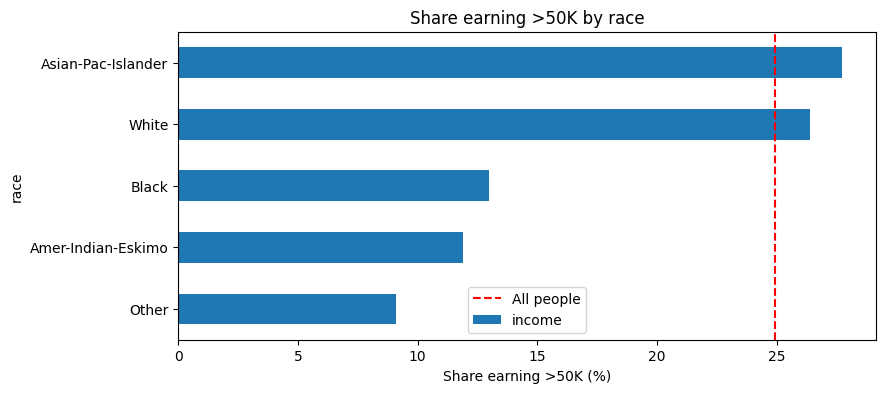

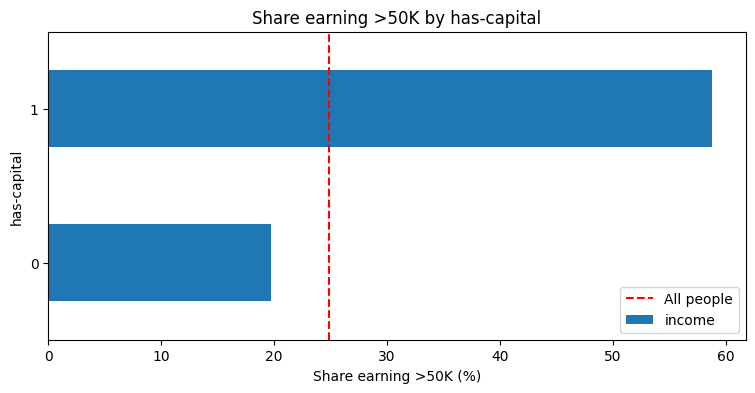

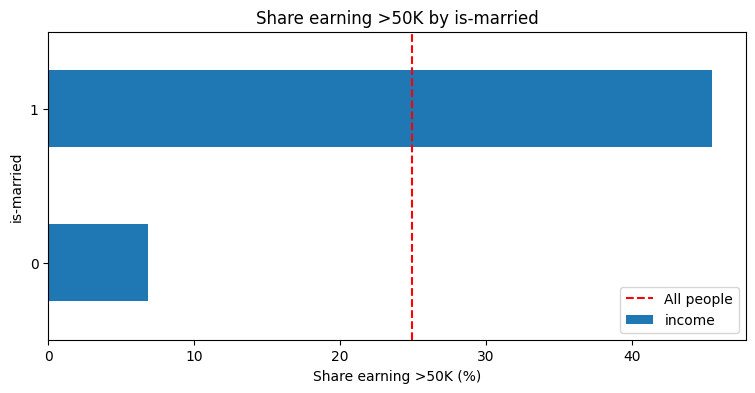

In [24]:
group_columns = [
    "sex",
    "age-group",
    "hours-category",
    "education",
    "marital-status",
    "occupation",
    "workclass",
    "race",
    "has-capital",
    "is-married"
]

overall_share = (train["income"] == ">50K").mean() * 100

for column in group_columns:

    share = (train["income"] == ">50K").groupby(train[column], observed=True).mean() * 100

    # Education is shown in the order of the education level, the rest from lowest to highest share
    if column == "education":
        order = train.groupby("education")["education-num"].first().sort_values().index
        share = share.reindex(order)
    else:
        share = share.sort_values()

    plt.figure(figsize=(9, 4))
    share.plot.barh()
    plt.axvline(overall_share, color="red", linestyle="--", label="All people")
    plt.xlabel("Share earning >50K (%)")
    plt.title(f"Share earning >50K by {column}")
    plt.legend()
    plt.show()

### Correlation of the encoded variables with income

The Pearson correlation of every encoded column with `income` (1 = earns >50K).

,Correlation with income
marital-status_Never-married,-0.3199
relationship_Own-child,-0.2262
relationship_Not-in-family,-0.1931
occupation_Other-service,-0.1660
relationship_Unmarried,-0.1459
workclass_Private,-0.1171
occupation_Handlers-cleaners,-0.0939
race_Black,-0.0884
relationship_Other-relative,-0.0845
occupation_Machine-op-inspct,-0.0762


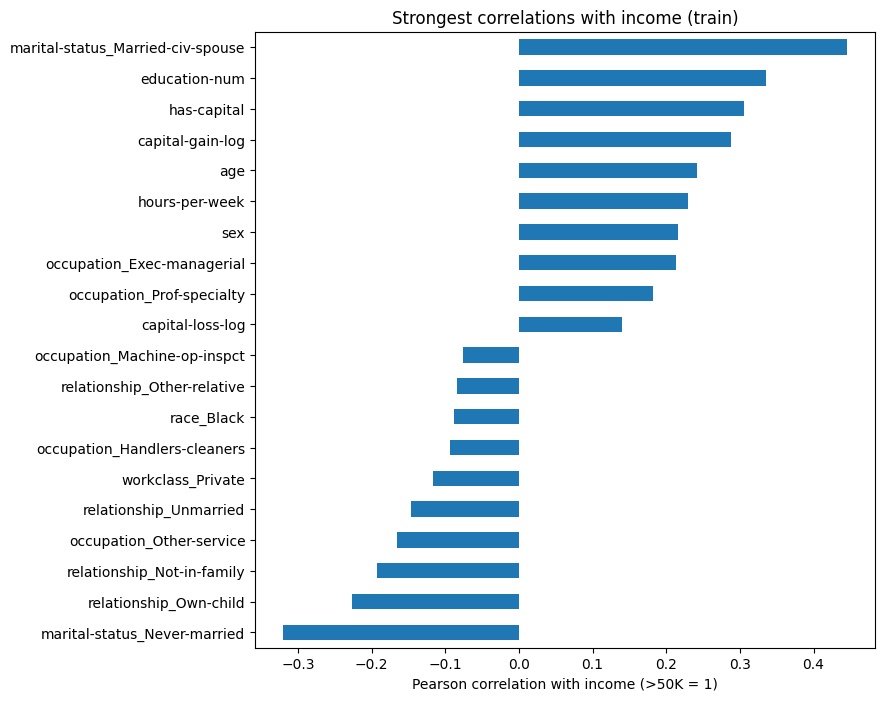

In [25]:
income_correlation = train_encoded.corrwith(y_train).sort_values()

display(income_correlation.round(4).to_frame("Correlation with income"))

# The 10 strongest negative and the 10 strongest positive correlations
strongest = pd.concat([income_correlation.head(10), income_correlation.tail(10)])

plt.figure(figsize=(8, 8))
strongest.plot.barh()
plt.xlabel("Pearson correlation with income (>50K = 1)")
plt.title("Strongest correlations with income (train)")
plt.show()

# Save the cleaned data

- `train_clean.csv`, `test_clean.csv`: cleaned data with the original categories, the log columns and the new features
- `train_encoded.csv`, `test_encoded.csv`: encoded data, `income` as 0/1 (for regression and the decision tree)
- `train_scaled.csv`, `test_scaled.csv`: encoded and standardized data, `income` as 0/1 (for clustering)

In [26]:
os.makedirs("cleaned_data", exist_ok=True)

train.to_csv("cleaned_data/train_clean.csv", index=False)
test.to_csv("cleaned_data/test_clean.csv", index=False)

train_encoded_with_income = train_encoded.copy()
train_encoded_with_income["income"] = y_train
train_encoded_with_income.to_csv("cleaned_data/train_encoded.csv", index=False)

test_encoded_with_income = test_encoded.copy()
test_encoded_with_income["income"] = y_test
test_encoded_with_income.to_csv("cleaned_data/test_encoded.csv", index=False)

train_scaled_with_income = train_scaled.copy()
train_scaled_with_income["income"] = y_train
train_scaled_with_income.to_csv("cleaned_data/train_scaled.csv", index=False)

test_scaled_with_income = test_scaled.copy()
test_scaled_with_income["income"] = y_test
test_scaled_with_income.to_csv("cleaned_data/test_scaled.csv", index=False)

print("Saved train_clean.csv:", train.shape, " test_clean.csv:", test.shape)
print("Saved train_encoded.csv:", train_encoded_with_income.shape, " test_encoded.csv:", test_encoded_with_income.shape)
print("Saved train_scaled.csv:", train_scaled_with_income.shape, " test_scaled.csv:", test_scaled_with_income.shape)

Saved train_clean.csv: (30139, 22)  test_clean.csv: (15055, 22)
Saved train_encoded.csv: (30139, 43)  test_encoded.csv: (15055, 43)
Saved train_scaled.csv: (30139, 43)  test_scaled.csv: (15055, 43)


# Summary

### Dataset
Adult Income: the training file `adult.data` (32,561 rows) and the test file `adult.test` (16,281 rows), 15 variables (6 numerical, 9 categorical). The target is `income` (>50K or <=50K). We kept the original split: the analysis is done on the training data, the test data is only cleaned and encoded the same way, and scaled with the values from the training data.

### Data cleaning
- Removed the dot from the income labels in the test file (`>50K.`).
- Deleted the rows with missing values (they were only in `workclass`, `occupation` and `native-country`): 2,399 in train (7.37%) and 1,221 in test (7.50%).
- Deleted 23 duplicate rows in train and 5 in test.
- 30,139 training and 15,055 test rows are left. 24.9% of people in train earn more than 50K (24.6% in test), so the classes are imbalanced.

### Outliers
z-score and IQR gave very different results because some variables are very skewed (over 90% of `capital-gain` and `capital-loss` are 0). We kept all values: the extreme values are real (people aged 90, 99 hours per week, large capital gains), not errors, and they are important for studying high incomes. We only added log(1 + x) versions of `capital-gain` and `capital-loss` to compress their very skewed scale (skewness of `capital-gain` from 11.9 to 3.07; `capital-loss` stays skewed, 4.27, because almost all values are 0).

### Feature engineering
`capital-net`, `has-capital`, `is-married`, `age-group`, `hours-category` and `is_us`.

### Encoding and standardization
`sex` and `native-country` became 0/1 columns, the other categorical variables were one-hot encoded (42 columns in total, the test data gets the same columns). The numerical columns were standardized with the mean and standard deviation of the training data.

## Findings (training data)
- The numerical variables are only weakly correlated with each other (all below 0.15).
- Strongest correlations with income: `Married-civ-spouse` (0.45), `education-num` (0.34), `has-capital` (0.31), `capital-gain-log` (0.29), age (0.24), `hours-per-week` (0.23). Strongest negative: `Never-married` (-0.32) and `Own-child` (-0.23).
- 45.5% of married people earn more than 50K, but only 6.8% of the others.
- People with capital gains or losses: 58.8% earn more than 50K, the rest: 19.8%.
- High income gets more common with age until 45-54 (40.5%), then it drops. Only 1.2% of people aged 17-24 earn more than 50K.
- Overtime: 40.7% earn more than 50K, part-time: 6.9%.